# Assignment 07 - Exploratory Data Analysis

This notebook performs a comprehensive exploratory data analysis (EDA) on the Banking Churn Prediction dataset. The analysis includes:

1. Data loading and initial inspection
2. Data quality assessment
3. Data cleaning
4. Univariate analysis
5. Bivariate analysis
6. Correlation analysis
7. Hypothesis testing (t-test, z-test, chi-square test)
8. Summary of findings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

## 1. Data Loading and Initial Inspection

We begin by loading the Banking Churn Prediction dataset and examining its structure, size, and basic statistics. The dataset contains information about bank customers and whether they have churned (closed their relationship with the bank).

In [2]:
df = pd.read_csv('Banking_churn_prediction.csv')

print(f"Dataset shape: {df.shape}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print()
df.head(10)

Dataset shape: (28382, 21)
Number of rows: 28382
Number of columns: 21



,customer_id,vintage,age,gender,dependents,occupation,city,customer_nw_category,branch_code,current_balance,...,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn,last_transaction
0,1,2101,66,Male,0.0,self_employed,187.0,2,755,1458.71,...,1458.71,1449.07,0.20,0.20,0.20,0.20,1458.71,1458.71,0,2019-05-21
1,2,2348,35,Male,0.0,self_employed,NaN,2,3214,5390.37,...,7799.26,12419.41,0.56,0.56,5486.27,100.56,6496.78,8787.61,0,2019-11-01
2,4,2194,31,Male,0.0,salaried,146.0,2,41,3913.16,...,4910.17,2815.94,0.61,0.61,6046.73,259.23,5006.28,5070.14,0,NaT
3,5,2329,90,NaN,NaN,self_employed,1020.0,2,582,2291.91,...,2084.54,1006.54,0.47,0.47,0.47,2143.33,2291.91,1669.79,1,2019-08-06
4,6,1579,42,Male,2.0,self_employed,1494.0,3,388,927.72,...,1643.31,1871.12,0.33,714.61,588.62,1538.06,1157.15,1677.16,1,2019-11-03
5,7,1923,42,Female,0.0,self_employed,1096.0,2,1666,15202.20,...,15211.29,13798.82,0.36,0.36,857.50,286.07,15719.44,15349.75,0,2019-11-01
6,8,2048,72,Male,0.0,retired,1020.0,1,1,7006.93,...,7859.74,11232.37,0.64,0.64,1299.64,439.26,7076.06,7755.98,0,2019-09-24
7,9,2009,46,Male,0.0,self_employed,623.0,2,317,10096.58,...,6511.82,16314.17,0.27,0.27,443.13,5688.44,8563.84,5317.04,0,2019-07-12
8,10,2053,31,Male,0.0,salaried,1096.0,2,4110,1355.86,...,1702.44,1126.13,714.51,121.09,714.51,359.44,1183.45,1857.42,0,2019-12-12
9,11,2295,40,Male,3.0,self_employed,1020.0,2,38,4957.95,...,2168.53,1864.33,6912.29,4206.13,1887.30,1348.85,1823.16,2416.69,0,2019-12-31


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 28382 entries, 0 to 28381
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   customer_id                     28382 non-null  int64  
 1   vintage                         28382 non-null  int64  
 2   age                             28382 non-null  int64  
 3   gender                          27857 non-null  str    
 4   dependents                      25919 non-null  float64
 5   occupation                      28302 non-null  str    
 6   city                            27579 non-null  float64
 7   customer_nw_category            28382 non-null  int64  
 8   branch_code                     28382 non-null  int64  
 9   current_balance                 28382 non-null  float64
 10  previous_month_end_balance      28382 non-null  float64
 11  average_monthly_balance_prevQ   28382 non-null  float64
 12  average_monthly_balance_prevQ2  28382 non-n

In [4]:
df.describe().round(2)

,customer_id,vintage,age,dependents,city,customer_nw_category,branch_code,current_balance,previous_month_end_balance,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn
count,28382.00,28382.00,28382.00,25919.00,27579.00,28382.00,28382.00,28382.00,28382.00,28382.00,28382.00,28382.00,28382.00,28382.00,28382.00,28382.00,28382.00,28382.00
mean,15143.51,2091.14,48.21,0.35,796.11,2.23,925.98,7380.55,7495.77,7496.78,7124.21,3433.25,3261.69,3658.74,3339.76,7451.13,7495.18,0.19
std,8746.45,272.68,17.81,1.00,432.87,0.66,937.80,42598.71,42529.35,41726.22,44575.81,77071.45,29688.89,51985.42,24301.11,42033.94,42431.98,0.39
min,1.00,73.00,1.00,0.00,0.00,1.00,1.00,-5503.96,-3149.57,1428.69,-16506.10,0.01,0.01,0.01,0.01,-3374.18,-5171.92,0.00
25%,7557.25,1958.00,36.00,0.00,409.00,2.00,176.00,1784.47,1906.00,2180.95,1832.51,0.31,0.33,0.41,0.41,1996.76,2074.41,0.00
50%,15150.50,2154.00,46.00,0.00,834.00,2.00,572.00,3281.26,3379.92,3542.86,3359.60,0.61,0.63,91.93,109.96,3448.00,3465.23,0.00
75%,22706.75,2292.00,60.00,0.00,1096.00,3.00,1440.00,6635.82,6656.54,6666.89,6517.96,707.27,749.24,1360.44,1357.55,6667.96,6654.69,0.00
max,30301.00,2476.00,90.00,52.00,1649.00,3.00,4782.00,5905904.03,5740438.63,5700289.57,5010170.10,12269845.39,2361808.29,7637857.36,1414168.06,5778184.77,5720144.50,1.00


In [5]:
df.describe(include='object')

,gender,occupation,last_transaction
count,27857,28302,28382
unique,2,5,361
top,Male,self_employed,NaT
freq,16548,17476,3223


## 2. Data Quality Assessment

We now examine the data for missing values, duplicates, and data type issues. Understanding data quality is essential before performing any analysis or hypothesis testing.

In [6]:
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing.sort_values('Missing Percentage', ascending=False)
missing[missing['Missing Count'] > 0]

,Missing Count,Missing Percentage
dependents,2463,8.68
city,803,2.83
gender,525,1.85
occupation,80,0.28


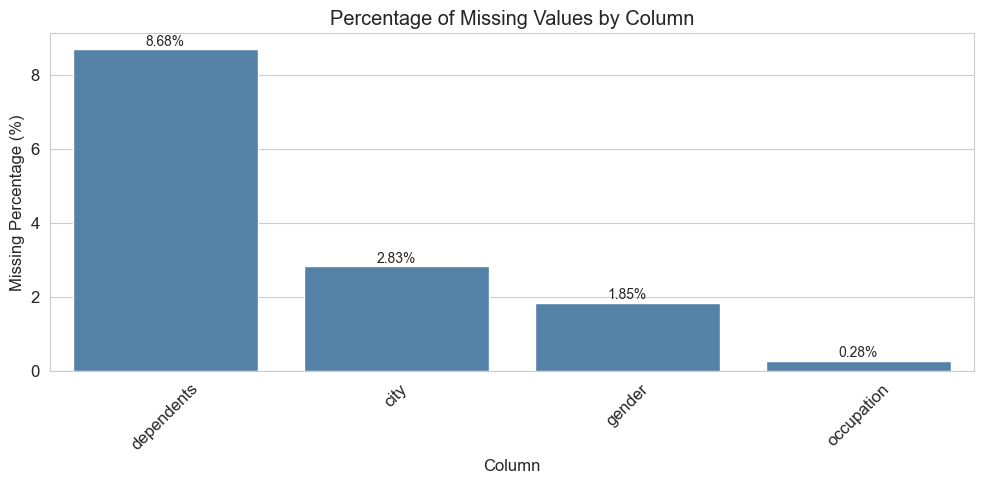

In [7]:
cols_with_missing = missing[missing['Missing Count'] > 0].index

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=cols_with_missing, y=missing.loc[cols_with_missing, 'Missing Percentage'], ax=ax,
            color='steelblue')
ax.set_title('Percentage of Missing Values by Column')
ax.set_xlabel('Column')
ax.set_ylabel('Missing Percentage (%)')
ax.tick_params(axis='x', rotation=45)
for i, col in enumerate(cols_with_missing):
    ax.text(i, missing.loc[col, 'Missing Percentage'] + 0.1,
            f"{missing.loc[col, 'Missing Percentage']}%", ha='center', fontsize=10)
plt.tight_layout()
plt.show()

In [8]:
print(f"Number of duplicate rows: {df.duplicated().sum()}")
print(f"Number of duplicate customer_ids: {df['customer_id'].duplicated().sum()}")

Number of duplicate rows: 0
Number of duplicate customer_ids: 0


## 3. Data Cleaning

Based on the data quality assessment, we address the following issues:

- **`gender`**: Contains missing values. Since gender is a categorical variable with few categories, we fill missing values with "Unknown" to preserve all rows and avoid introducing bias by imputing a specific gender.
- **`dependents`**: Numerical variable with missing values. We fill with the median since it is robust to outliers.
- **`city`**: Has missing values. We fill with a placeholder value (-1) to indicate unknown city, keeping these rows in the analysis.
- **`last_transaction`**: Contains NaT (Not a Time) values. We parse it as datetime and leave NaT values as-is, since this column is not used in our numerical or categorical hypothesis testing.
- **`customer_id`**: This is a unique identifier, not a feature. We keep it for reference but exclude it from analysis.

In [9]:
df_clean = df.copy()

df_clean['gender'] = df_clean['gender'].fillna('Unknown')
df_clean['dependents'] = df_clean['dependents'].fillna(df_clean['dependents'].median())
df_clean['city'] = df_clean['city'].fillna(-1)
df_clean['last_transaction'] = pd.to_datetime(df_clean['last_transaction'], errors='coerce')

print("Missing values after cleaning:")
remaining = df_clean.isnull().sum()
remaining = remaining[remaining > 0]
if len(remaining) > 0:
    print(remaining)
    print("\nNote: NaT values in 'last_transaction' are expected and will not affect our analysis.")
else:
    print("No missing values remain.")

Missing values after cleaning:
occupation            80
last_transaction    3223
dtype: int64

Note: NaT values in 'last_transaction' are expected and will not affect our analysis.


In [10]:
print("Cleaned dataset shape:", df_clean.shape)
print("\nData types after cleaning:")
print(df_clean.dtypes)

Cleaned dataset shape: (28382, 21)

Data types after cleaning:
customer_id                                int64
vintage                                    int64
age                                        int64
gender                                       str
dependents                               float64
occupation                                   str
city                                     float64
customer_nw_category                       int64
branch_code                                int64
current_balance                          float64
previous_month_end_balance               float64
average_monthly_balance_prevQ            float64
average_monthly_balance_prevQ2           float64
current_month_credit                     float64
previous_month_credit                    float64
current_month_debit                      float64
previous_month_debit                     float64
current_month_balance                    float64
previous_month_balance                   float64
churn 

## 4. Univariate Analysis

We examine the distribution of individual variables to understand their central tendencies, spread, and potential outliers.

### 4.1 Target Variable: Churn

The target variable `churn` indicates whether a customer has left the bank (1) or not (0). Understanding its distribution helps us identify class imbalance, which is common in churn datasets.

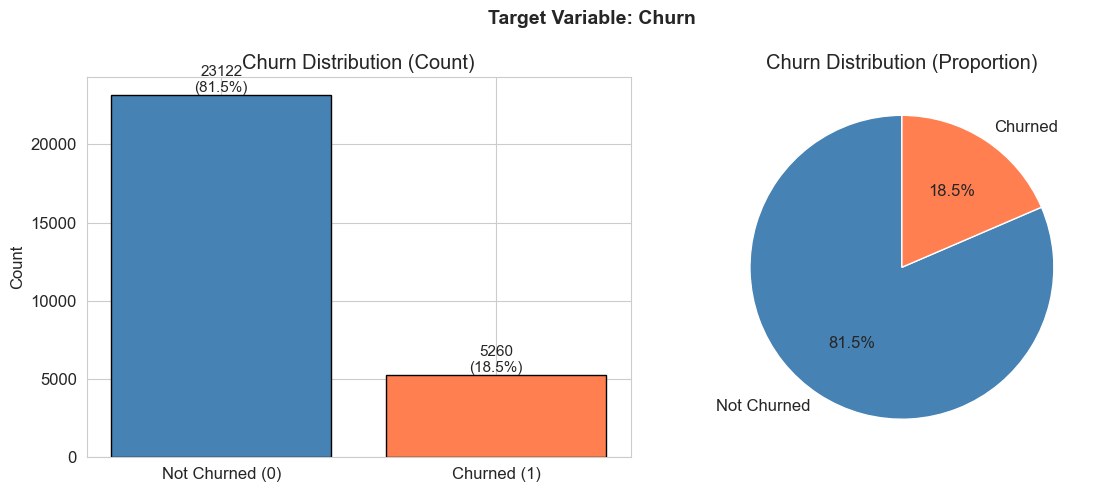

Churn rate: 18.53%
Class ratio (Not Churned : Churned): 4.40 : 1


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

churn_counts = df_clean['churn'].value_counts()
churn_pct = df_clean['churn'].value_counts(normalize=True) * 100

axes[0].bar(['Not Churned (0)', 'Churned (1)'], churn_counts.values,
            color=['steelblue', 'coral'], edgecolor='black')
axes[0].set_title('Churn Distribution (Count)')
axes[0].set_ylabel('Count')
for i, (count, pct) in enumerate(zip(churn_counts.values, churn_pct.values)):
    axes[0].text(i, count + 200, f'{count}\n({pct:.1f}%)', ha='center', fontsize=11)

axes[1].pie(churn_counts.values, labels=['Not Churned', 'Churned'],
            autopct='%1.1f%%', colors=['steelblue', 'coral'], startangle=90)
axes[1].set_title('Churn Distribution (Proportion)')

plt.suptitle('Target Variable: Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Churn rate: {churn_pct.iloc[1]:.2f}%")
print(f"Class ratio (Not Churned : Churned): {churn_counts.iloc[0] / churn_counts.iloc[1]:.2f} : 1")

**Observation:** The dataset exhibits class imbalance -- the majority of customers have not churned. This is typical in churn prediction scenarios. The exact churn rate and class ratio are reported above. This imbalance should be kept in mind when interpreting results.

### 4.2 Numerical Variables

We now examine the distributions of all numerical features using histograms. The red dashed line represents the mean, and the green solid line represents the median. A large gap between mean and median indicates skewness.

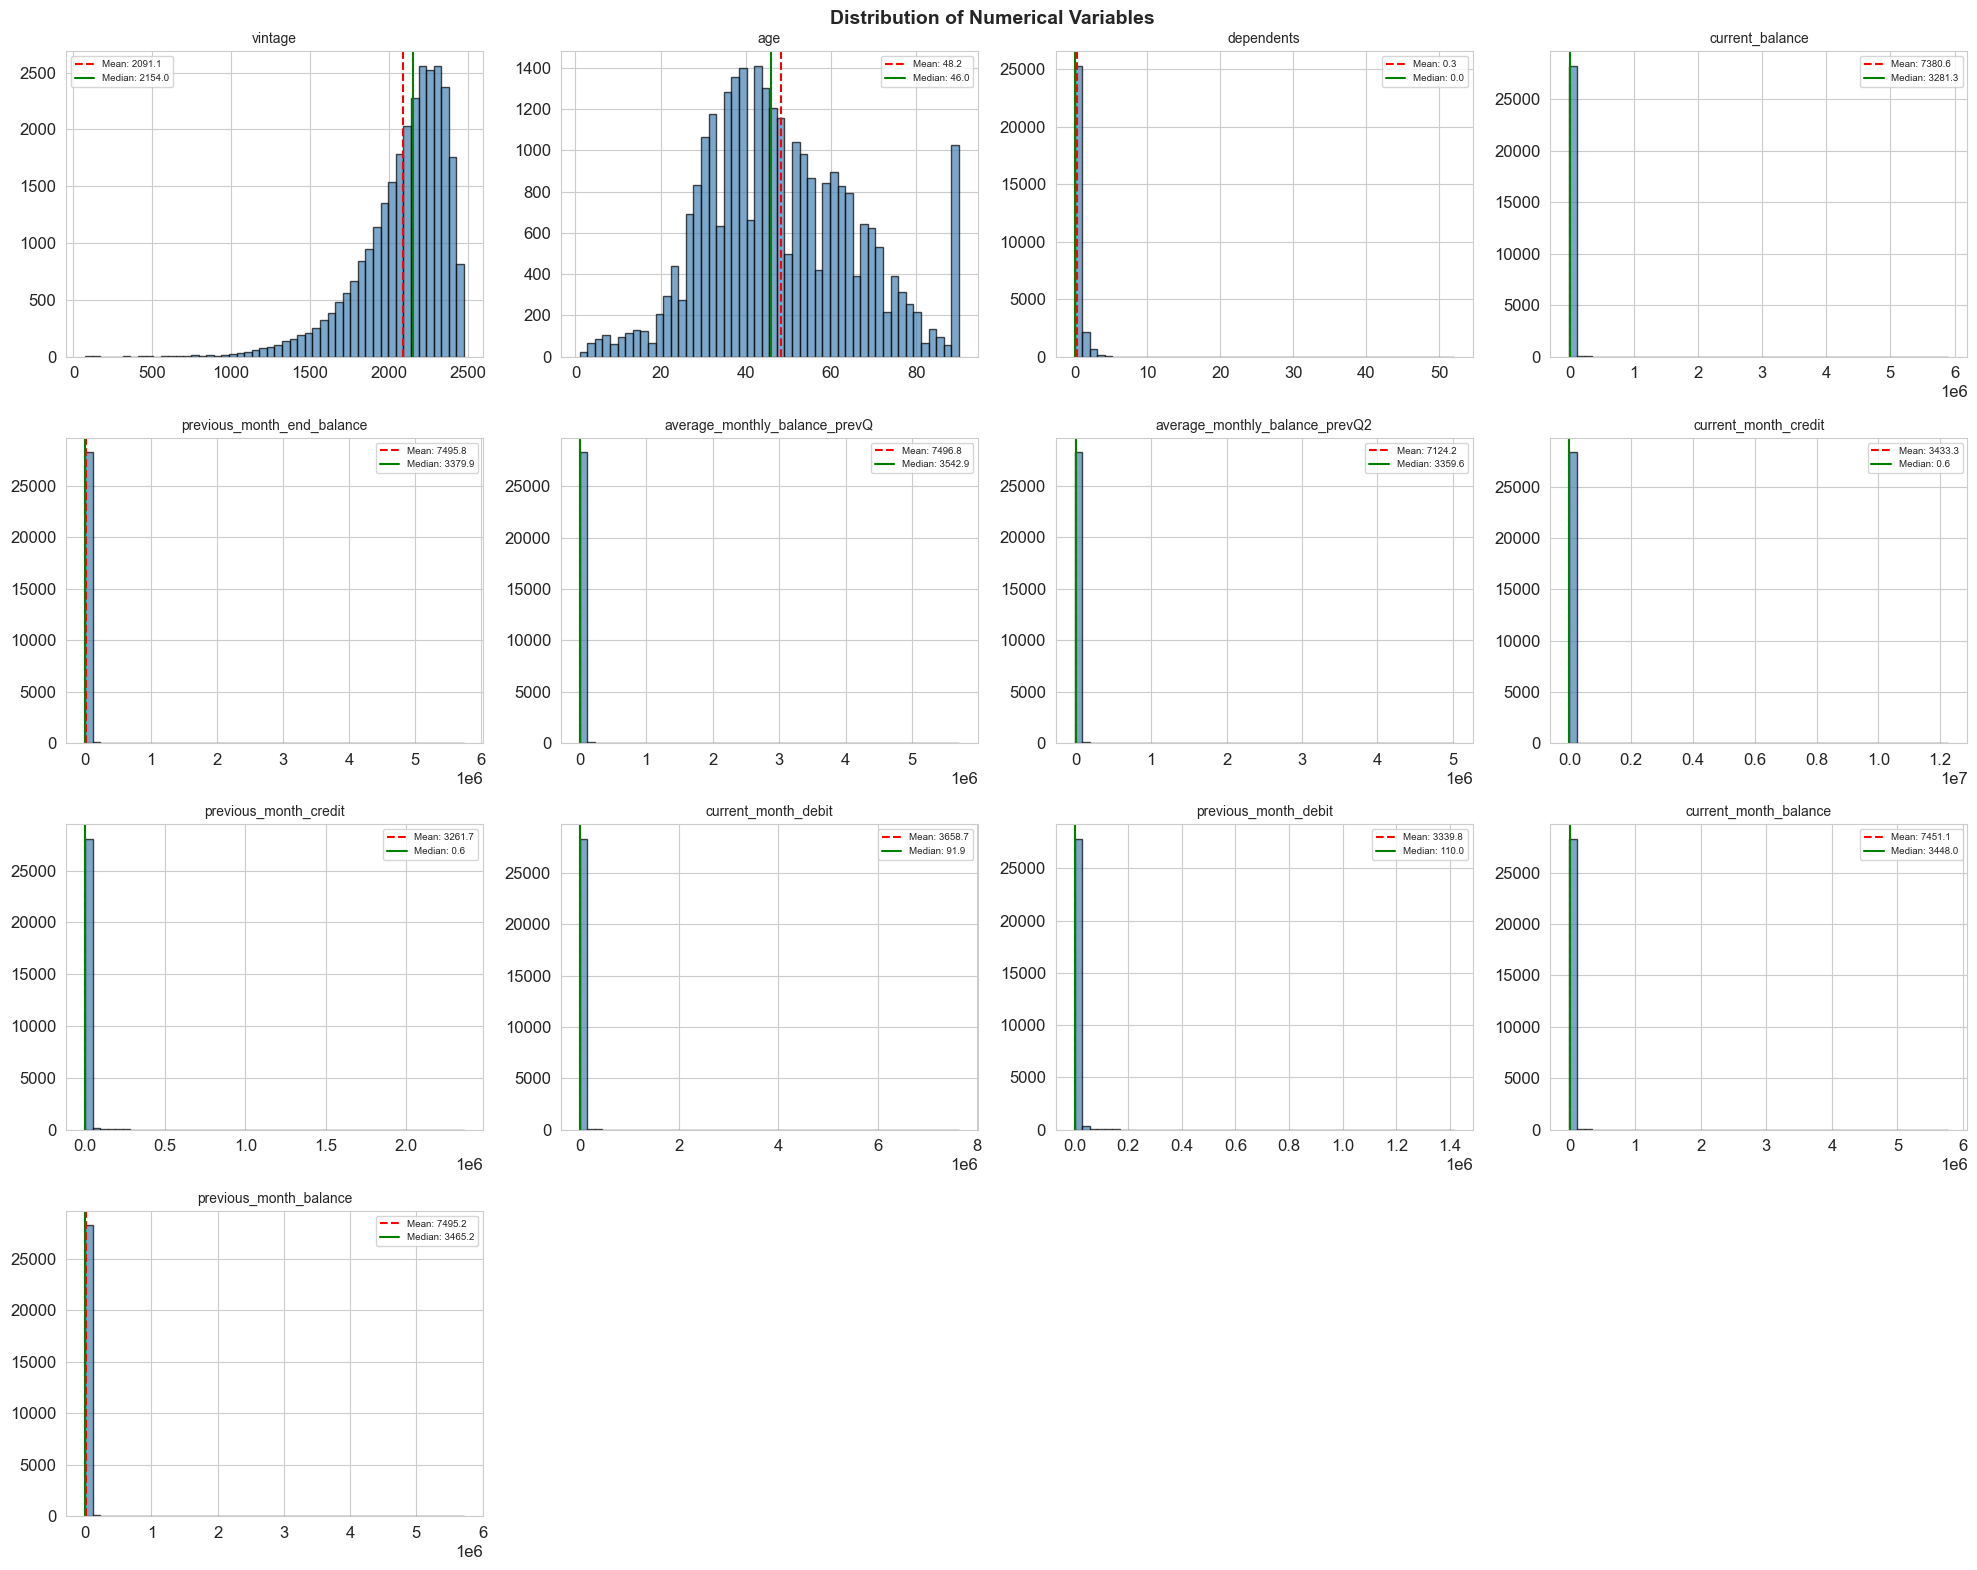

In [12]:
numerical_cols = ['vintage', 'age', 'dependents', 'current_balance',
                  'previous_month_end_balance', 'average_monthly_balance_prevQ',
                  'average_monthly_balance_prevQ2', 'current_month_credit',
                  'previous_month_credit', 'current_month_debit',
                  'previous_month_debit', 'current_month_balance',
                  'previous_month_balance']

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df_clean[col], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].axvline(df_clean[col].mean(), color='red', linestyle='--',
                    label=f'Mean: {df_clean[col].mean():.1f}')
    axes[i].axvline(df_clean[col].median(), color='green', linestyle='-',
                    label=f'Median: {df_clean[col].median():.1f}')
    axes[i].set_title(col, fontsize=10)
    axes[i].legend(fontsize=7)

for j in range(len(numerical_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Numerical Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
df_clean[numerical_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
vintage,28382.0,2091.14,272.68,73.00,1958.00,2154.00,2292.00,2476.00
age,28382.0,48.21,17.81,1.00,36.00,46.00,60.00,90.00
dependents,28382.0,0.32,0.96,0.00,0.00,0.00,0.00,52.00
current_balance,28382.0,7380.55,42598.71,-5503.96,1784.47,3281.26,6635.82,5905904.03
previous_month_end_balance,28382.0,7495.77,42529.35,-3149.57,1906.00,3379.92,6656.54,5740438.63
average_monthly_balance_prevQ,28382.0,7496.78,41726.22,1428.69,2180.95,3542.86,6666.89,5700289.57
average_monthly_balance_prevQ2,28382.0,7124.21,44575.81,-16506.10,1832.51,3359.60,6517.96,5010170.10
current_month_credit,28382.0,3433.25,77071.45,0.01,0.31,0.61,707.27,12269845.39
previous_month_credit,28382.0,3261.69,29688.89,0.01,0.33,0.63,749.24,2361808.29
current_month_debit,28382.0,3658.74,51985.42,0.01,0.41,91.93,1360.44,7637857.36


### 4.3 Categorical Variables

We examine the distribution of categorical features: `gender`, `occupation`, and `customer_nw_category`. Understanding the frequency of each category helps identify dominant groups and rare categories.

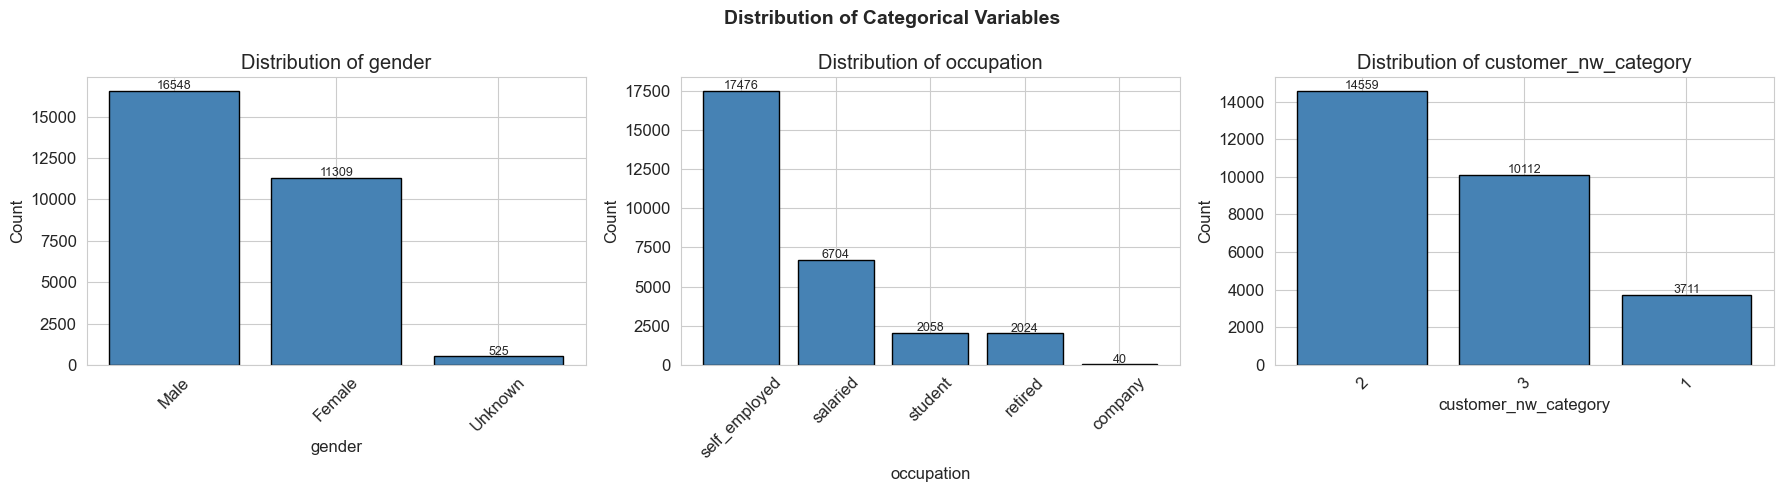

In [14]:
categorical_cols = ['gender', 'occupation', 'customer_nw_category']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(categorical_cols):
    counts = df_clean[col].value_counts()
    bars = axes[i].bar(counts.index.astype(str), counts.values,
                       color='steelblue', edgecolor='black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)
    for bar, val in zip(bars, counts.values):
        axes[i].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 100,
                     str(val), ha='center', fontsize=9)

plt.suptitle('Distribution of Categorical Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Bivariate Analysis

We now explore the relationship between features and the target variable (churn). This helps identify which features differ meaningfully between churned and non-churned customers.

### 5.1 Numerical Variables vs Churn

Box plots allow us to compare the distribution of numerical features between the two churn groups. Differences in medians, spread, or outlier patterns suggest a relationship between the feature and churn.

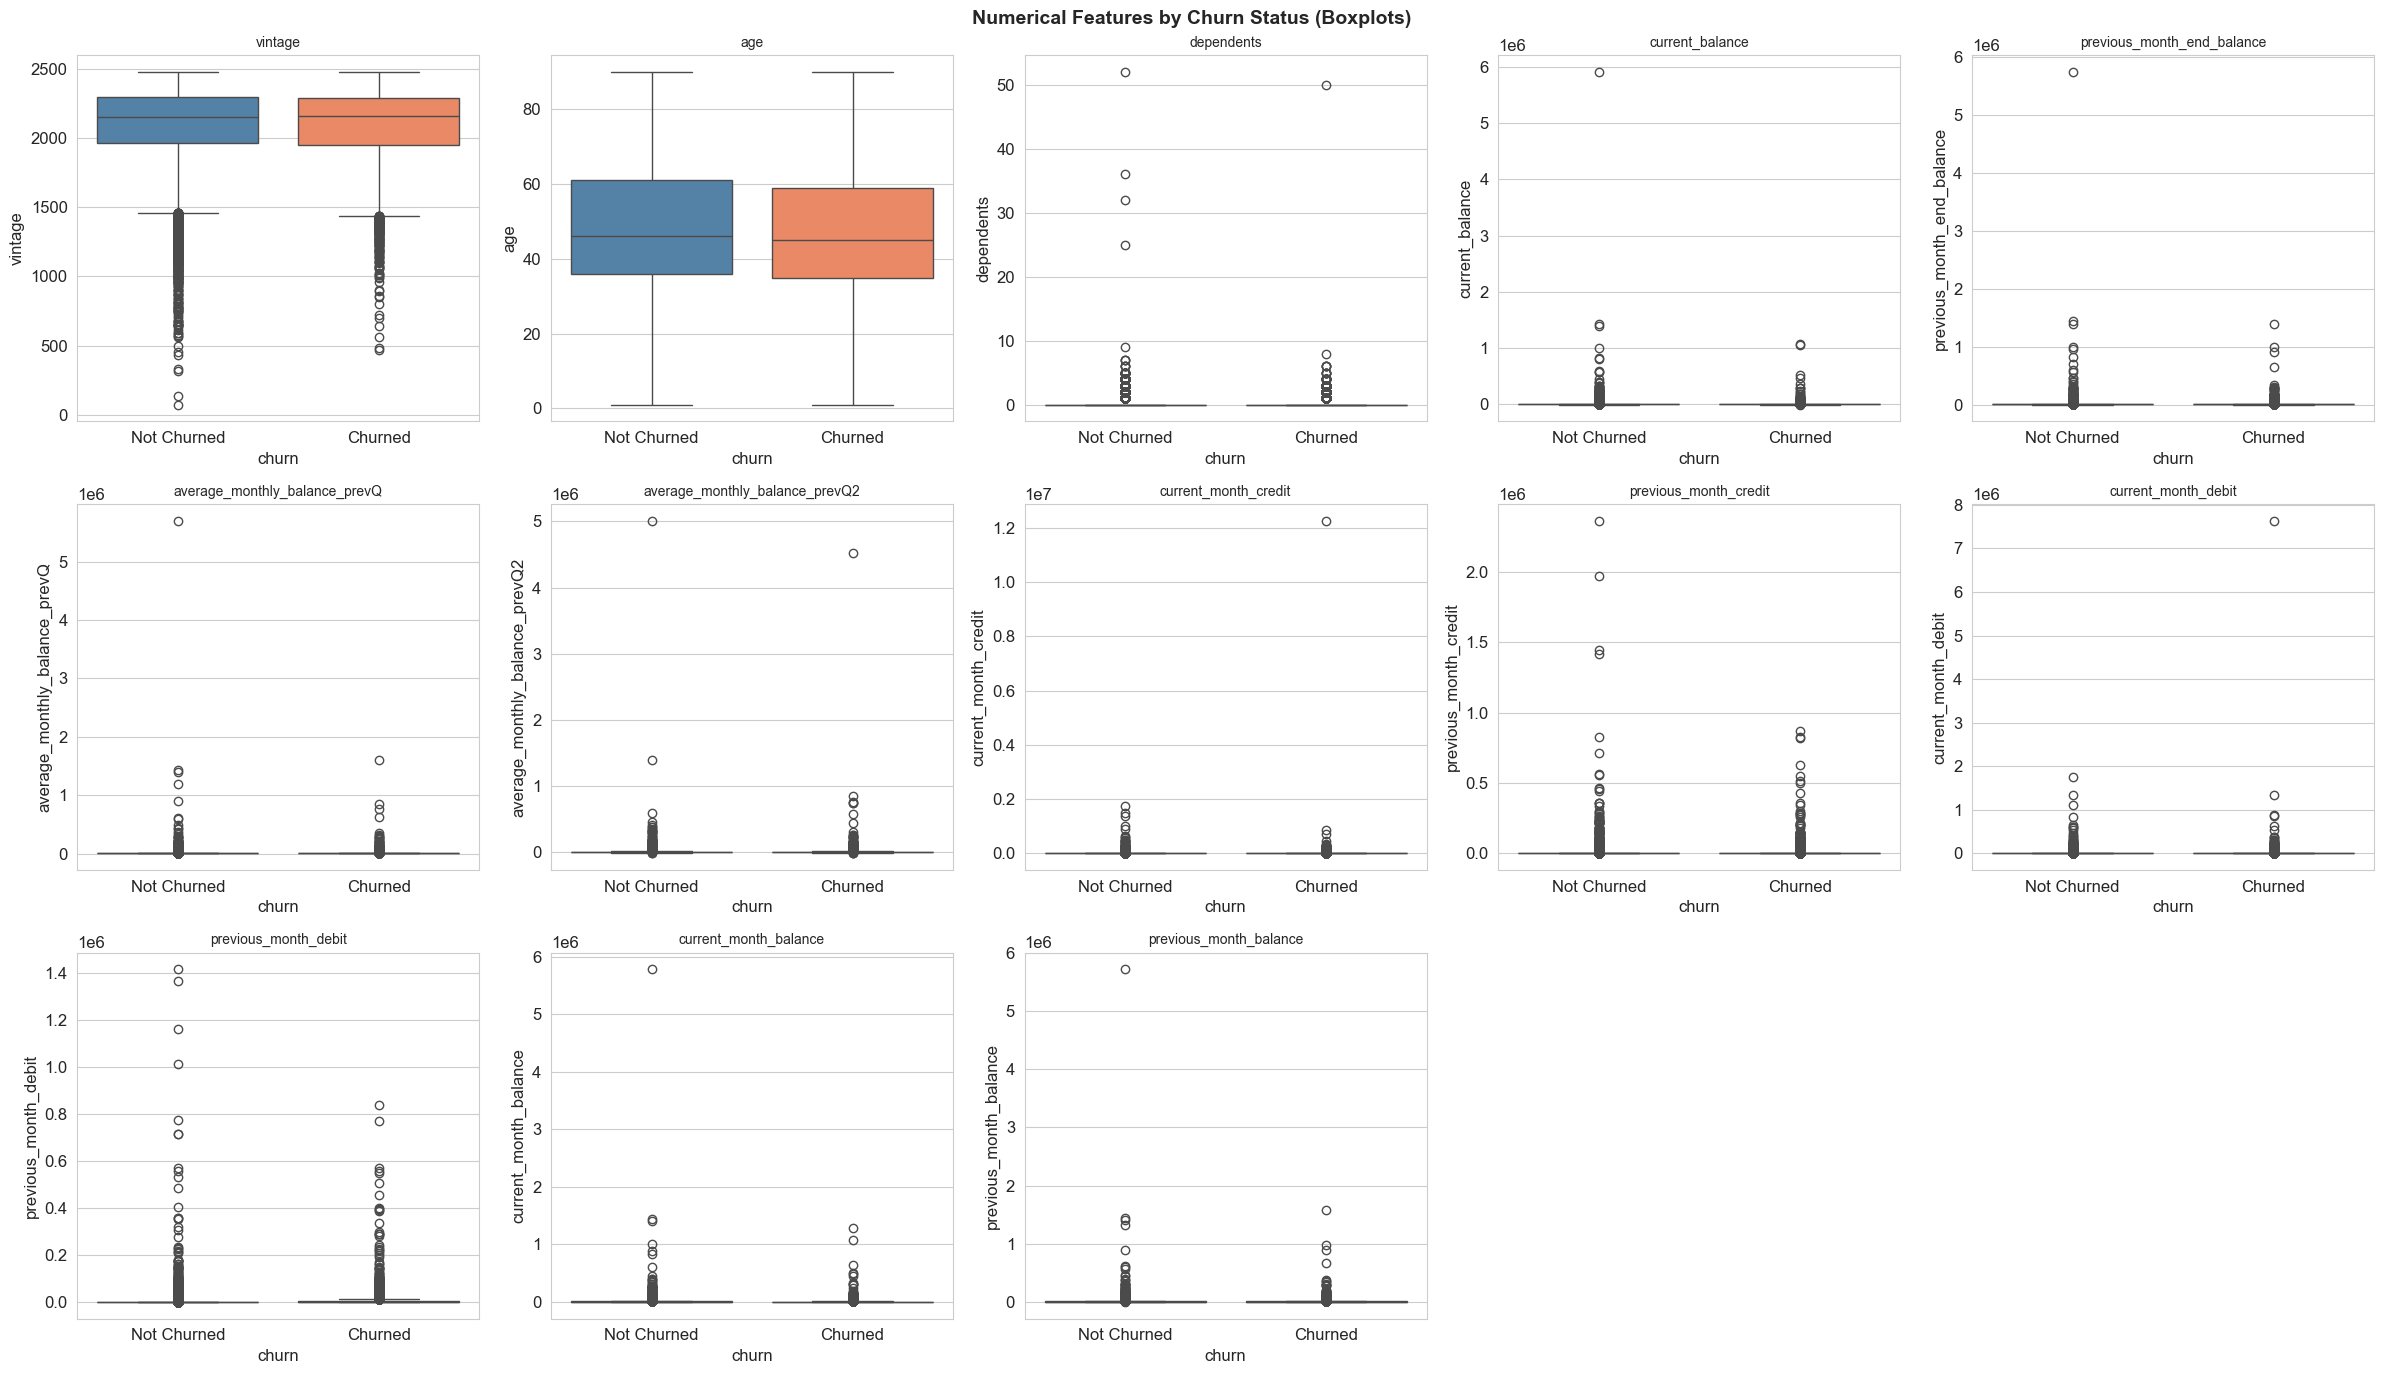

In [15]:
fig, axes = plt.subplots(3, 5, figsize=(24, 14))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df_clean, x='churn', y=col, ax=axes[i],
                palette=['steelblue', 'coral'])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xticklabels(['Not Churned', 'Churned'])

for j in range(len(numerical_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Features by Churn Status (Boxplots)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

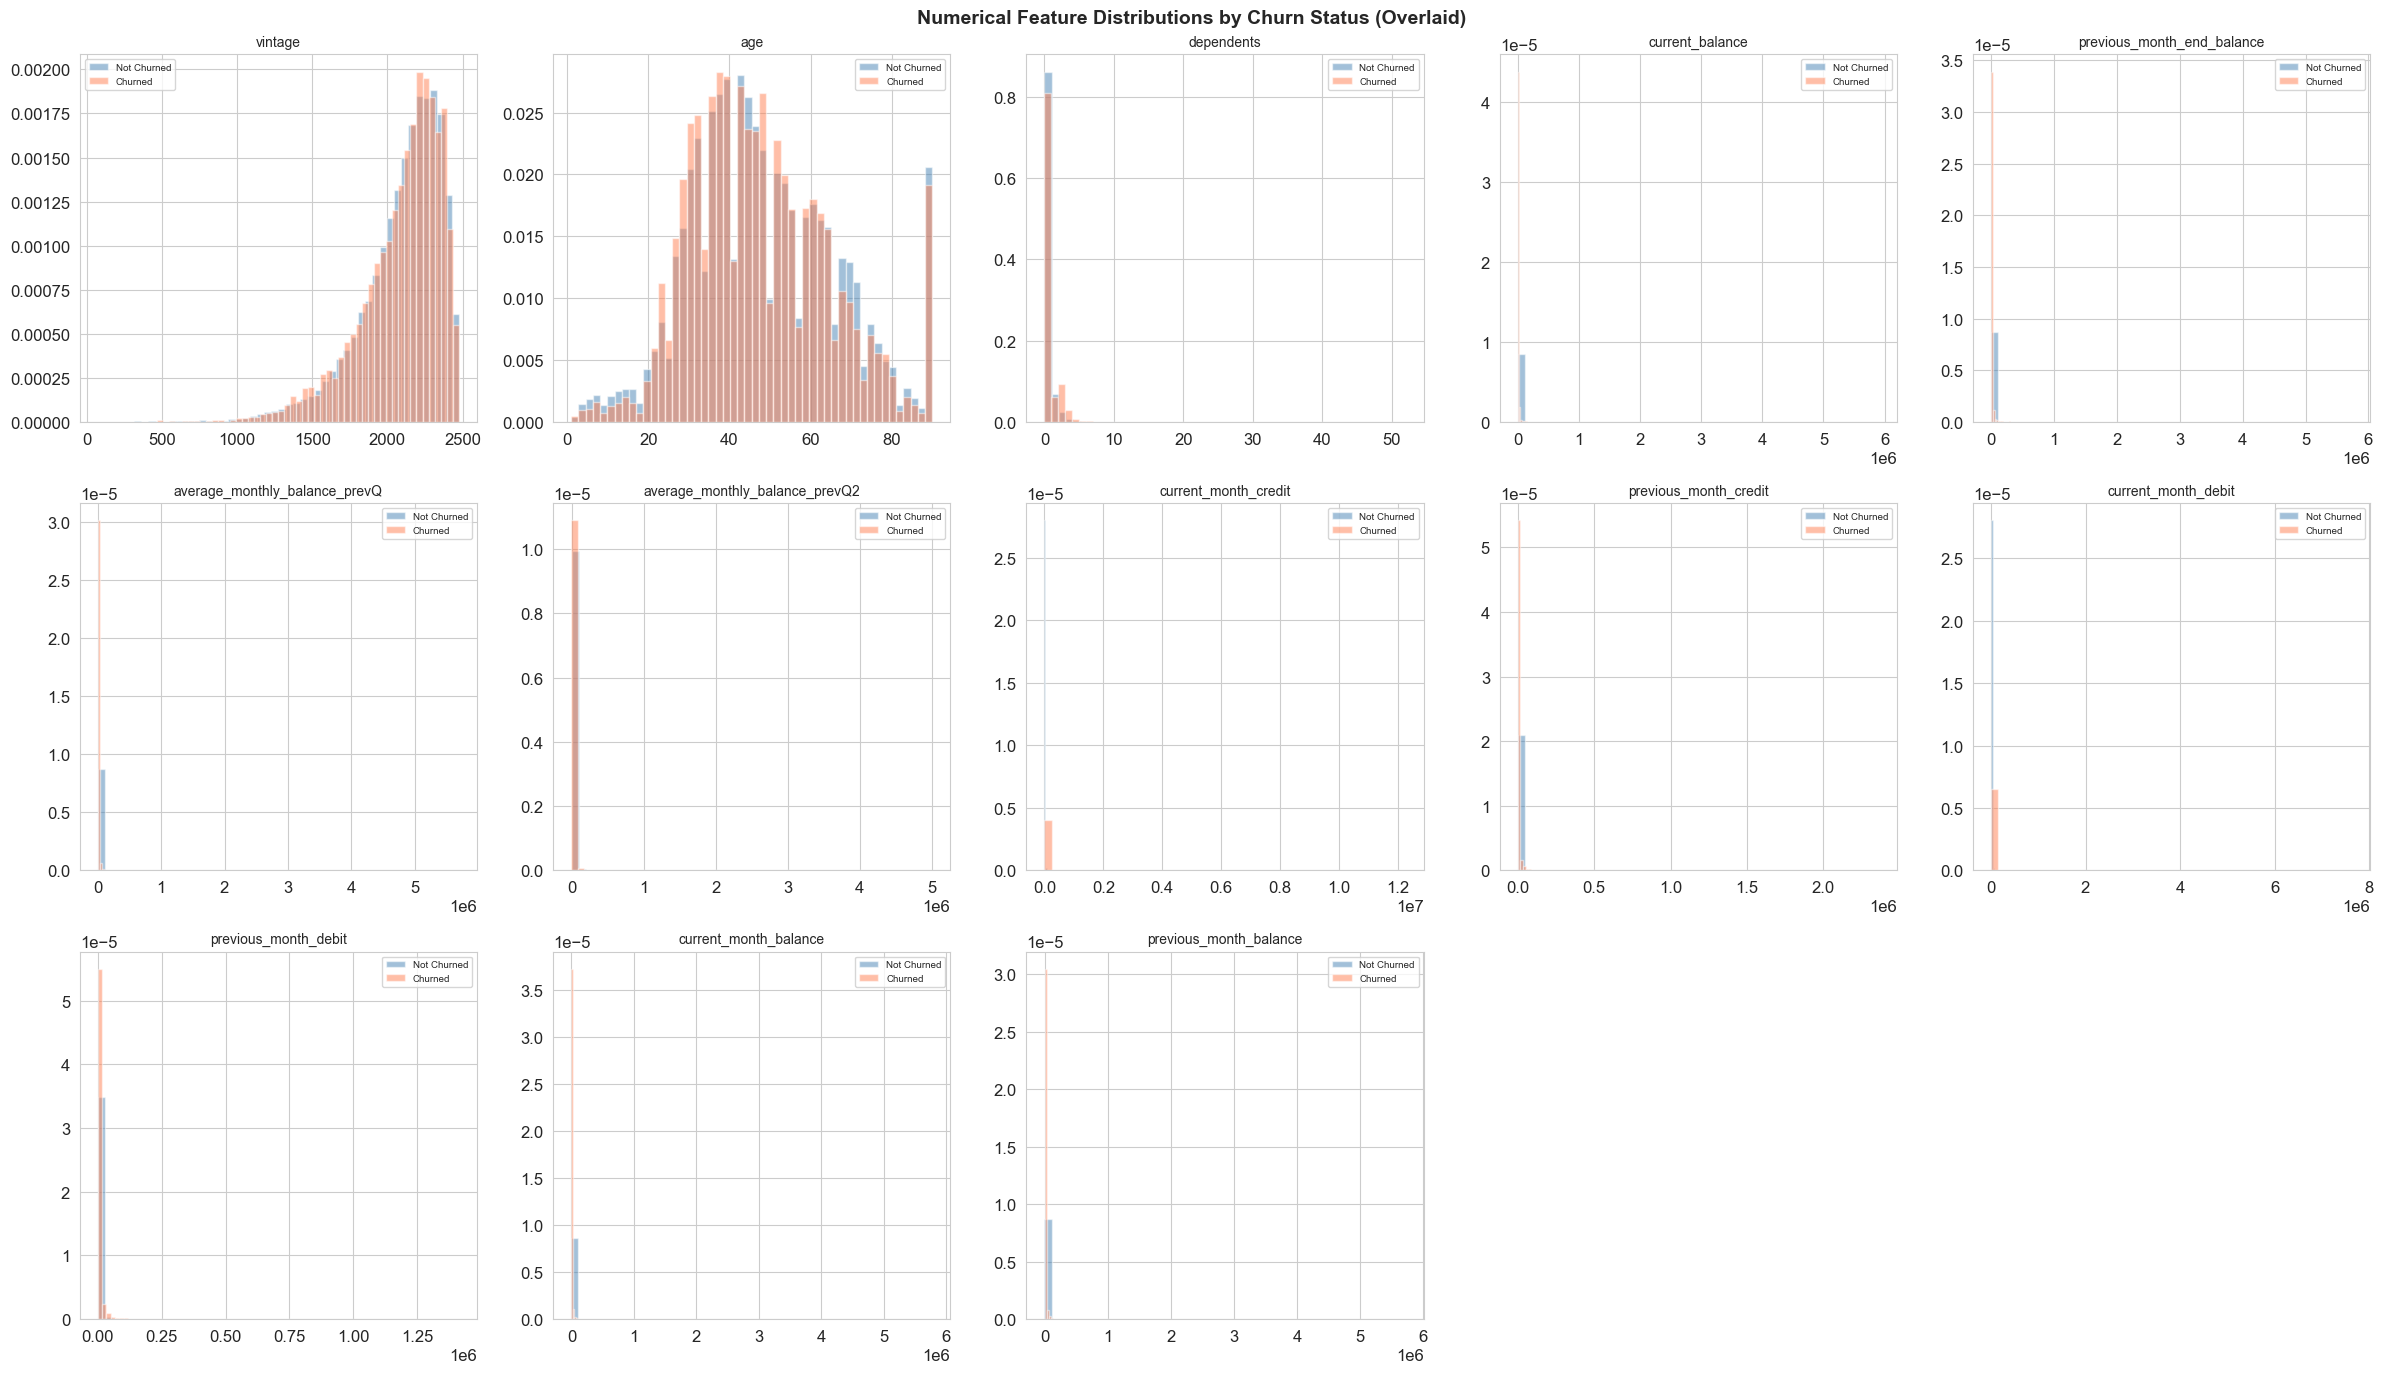

In [16]:
fig, axes = plt.subplots(3, 5, figsize=(24, 14))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    for churn_val, color, label in [(0, 'steelblue', 'Not Churned'),
                                     (1, 'coral', 'Churned')]:
        subset = df_clean[df_clean['churn'] == churn_val][col].dropna()
        axes[i].hist(subset, bins=50, alpha=0.5, color=color, label=label, density=True)
    axes[i].set_title(col, fontsize=10)
    axes[i].legend(fontsize=7)

for j in range(len(numerical_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions by Churn Status (Overlaid)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.2 Categorical Variables vs Churn

We examine churn rates across categories of each categorical variable. Stacked percentage bar plots reveal whether certain groups exhibit higher churn rates than others.

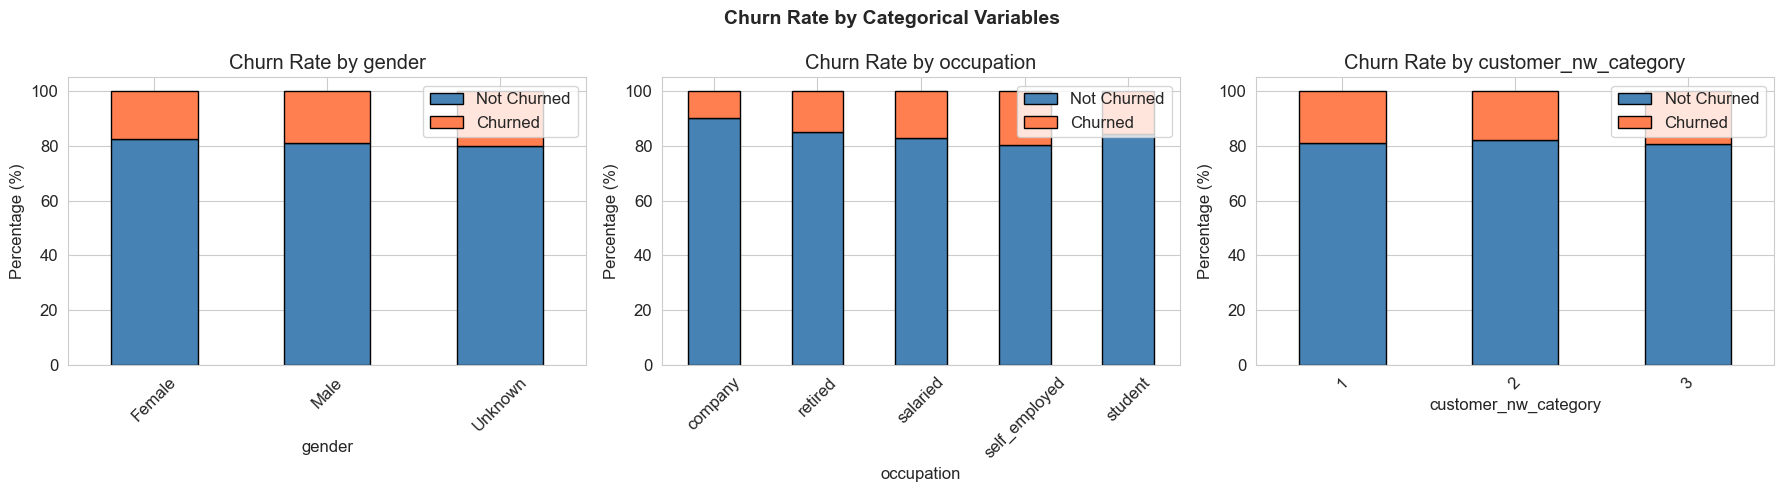

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(categorical_cols):
    ct = pd.crosstab(df_clean[col], df_clean['churn'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[i], color=['steelblue', 'coral'],
            edgecolor='black')
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Percentage (%)')
    axes[i].legend(['Not Churned', 'Churned'], loc='upper right')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Churn Rate by Categorical Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
for col in categorical_cols:
    print(f"\n--- Churn Rate by {col} ---")
    ct = pd.crosstab(df_clean[col], df_clean['churn'])
    ct.columns = ['Not Churned', 'Churned']
    ct['Total'] = ct.sum(axis=1)
    ct['Churn Rate (%)'] = (ct['Churned'] / ct['Total'] * 100).round(2)
    print(ct)


--- Churn Rate by gender ---
         Not Churned  Churned  Total  Churn Rate (%)
gender                                              
Female          9324     1985  11309           17.55
Male           13379     3169  16548           19.15
Unknown          419      106    525           20.19

--- Churn Rate by occupation ---
               Not Churned  Churned  Total  Churn Rate (%)
occupation                                                
company                 36        4     40           10.00
retired               1719      305   2024           15.07
salaried              5557     1147   6704           17.11
self_employed        14009     3467  17476           19.84
student               1734      324   2058           15.74

--- Churn Rate by customer_nw_category ---
                      Not Churned  Churned  Total  Churn Rate (%)
customer_nw_category                                             
1                            3001      710   3711           19.13
2               

### 5.3 Correlation Analysis

We compute the Pearson correlation matrix among all numerical features and the target variable `churn`. This reveals linear relationships between variables. High correlations between features may indicate redundancy, while correlations with churn indicate predictive potential.

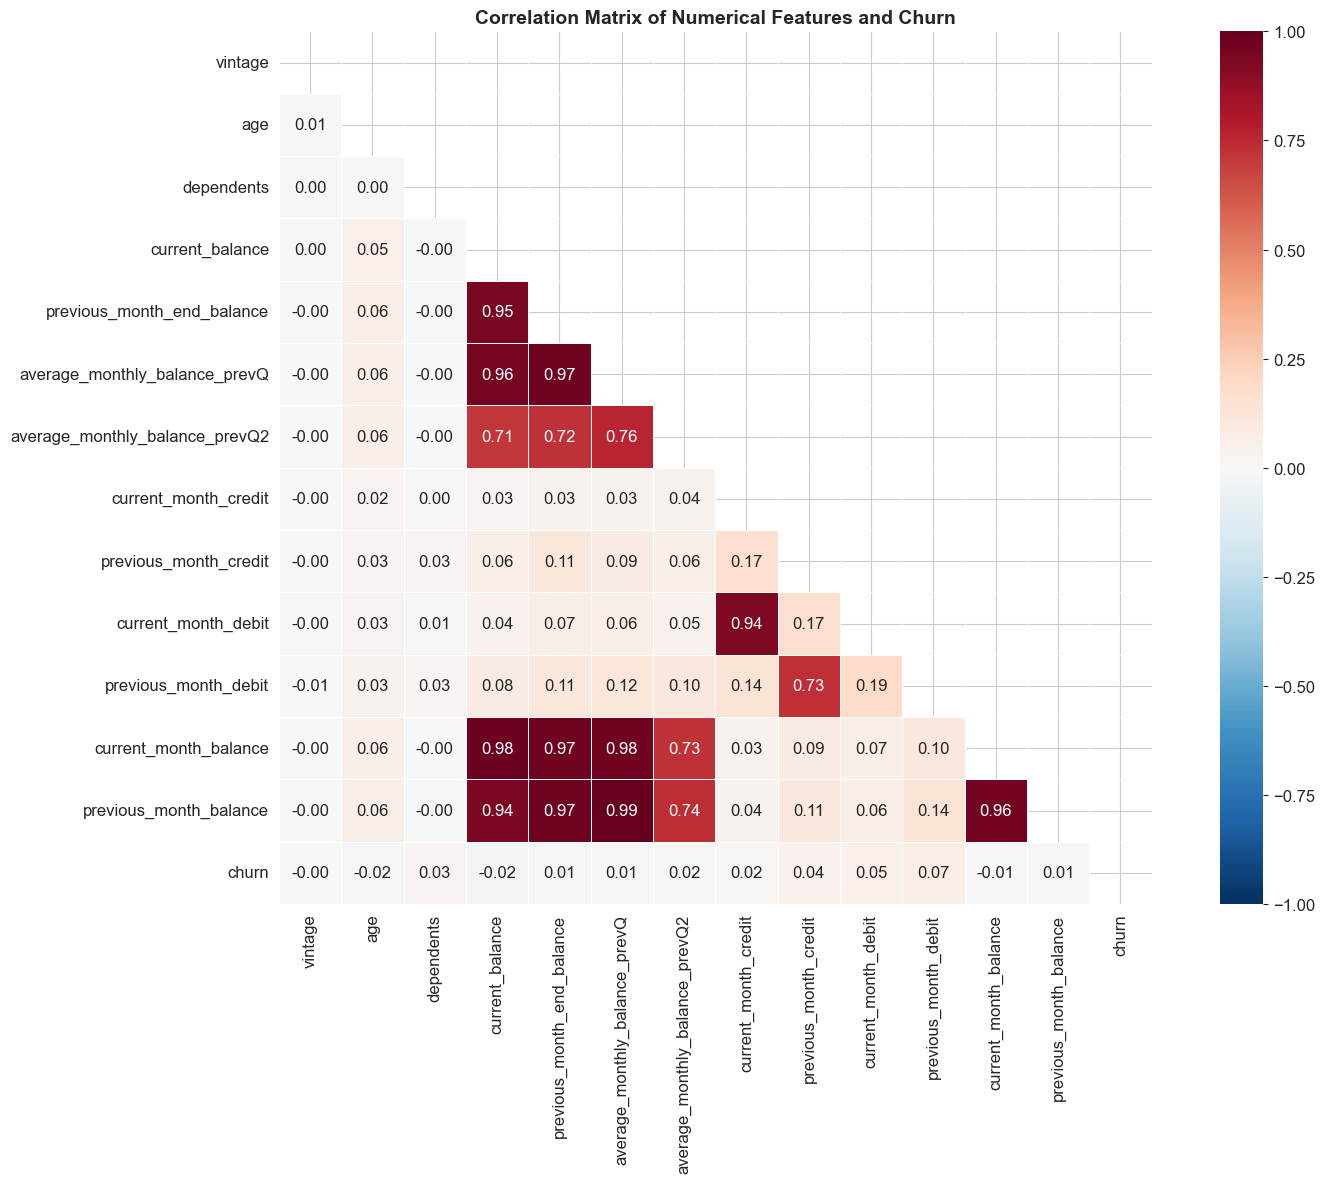

In [19]:
corr_matrix = df_clean[numerical_cols + ['churn']].corr()

fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Matrix of Numerical Features and Churn',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
churn_corr = corr_matrix['churn'].drop('churn').sort_values(key=abs, ascending=False)
print("Correlation of numerical features with churn (sorted by absolute value):")
print(churn_corr.round(4).to_string())

Correlation of numerical features with churn (sorted by absolute value):
previous_month_debit              0.0731
current_month_debit               0.0480
previous_month_credit             0.0422
dependents                        0.0293
current_balance                  -0.0242
current_month_credit              0.0208
age                              -0.0200
average_monthly_balance_prevQ2    0.0184
previous_month_balance            0.0146
average_monthly_balance_prevQ     0.0120
previous_month_end_balance        0.0069
current_month_balance            -0.0064
vintage                          -0.0048


## 6. Deeper Analysis

We examine churn rates across combinations of categorical features to uncover potential interaction effects that single-variable analysis might miss.

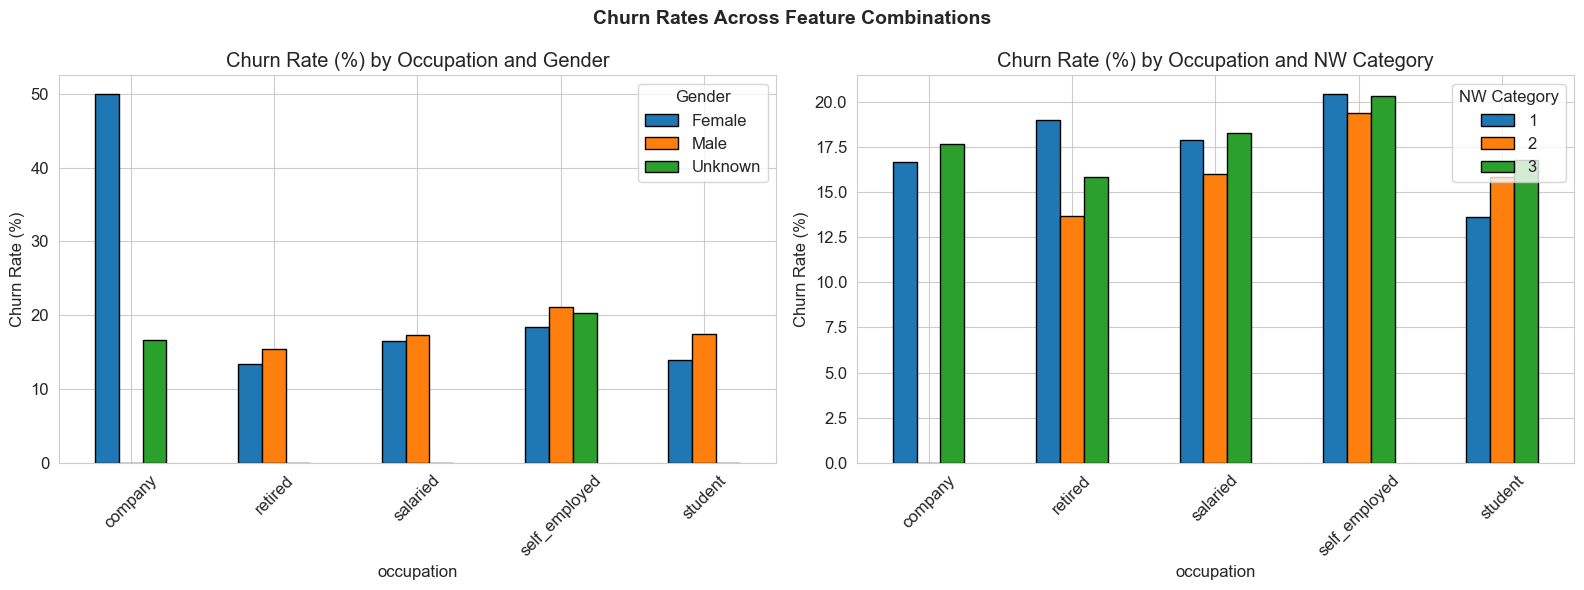

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ct1 = df_clean.groupby(['occupation', 'gender'])['churn'].mean() * 100
ct1_unstacked = ct1.unstack()
ct1_unstacked.plot(kind='bar', ax=axes[0], edgecolor='black')
axes[0].set_title('Churn Rate (%) by Occupation and Gender')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Gender')

ct2 = df_clean.groupby(['occupation', 'customer_nw_category'])['churn'].mean() * 100
ct2_unstacked = ct2.unstack()
ct2_unstacked.plot(kind='bar', ax=axes[1], edgecolor='black')
axes[1].set_title('Churn Rate (%) by Occupation and NW Category')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='NW Category')

plt.suptitle('Churn Rates Across Feature Combinations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Hypothesis Testing

In this section, we apply three types of hypothesis tests to establish statistical relationships among variables:

1. **Two-sample t-test**: To compare means of numerical variables between churned and non-churned groups.
2. **Z-test for proportions**: To compare churn proportions across categorical groups.
3. **Chi-square test of independence**: To test whether categorical variables are independent of churn.

For all tests, we use a significance level of **alpha = 0.05**.

**Decision rule**: If the p-value is less than alpha (0.05), we reject the null hypothesis.

### 7.1 Two-Sample T-Tests

We use **Welch's two-sample t-test** to test whether the mean of a numerical variable differs significantly between churned and non-churned customers. Welch's t-test does not assume equal variances between the two groups, making it more robust than the standard Student's t-test.

**For each numerical variable tested:**
- **H0 (Null Hypothesis)**: The mean of the variable is the same for churned and non-churned customers. (mu_churned = mu_not_churned)
- **H1 (Alternative Hypothesis)**: The mean of the variable is different for churned and non-churned customers. (mu_churned != mu_not_churned)

**Test**: `scipy.stats.ttest_ind` with `equal_var=False` (Welch's t-test)
**Significance level**: alpha = 0.05

In [22]:
alpha = 0.05

churned = df_clean[df_clean['churn'] == 1]
not_churned = df_clean[df_clean['churn'] == 0]

test_cols = ['age', 'vintage', 'current_balance', 'previous_month_end_balance',
             'average_monthly_balance_prevQ', 'average_monthly_balance_prevQ2',
             'current_month_credit', 'previous_month_credit',
             'current_month_debit', 'previous_month_debit',
             'current_month_balance', 'previous_month_balance']

ttest_results = []

for col in test_cols:
    group_churned = churned[col].dropna()
    group_not_churned = not_churned[col].dropna()

    t_stat, p_value = stats.ttest_ind(group_churned, group_not_churned, equal_var=False)

    ttest_results.append({
        'Variable': col,
        'Mean (Churned)': round(group_churned.mean(), 2),
        'Mean (Not Churned)': round(group_not_churned.mean(), 2),
        'T-Statistic': round(t_stat, 4),
        'P-Value': round(p_value, 6),
        'Reject H0': 'Yes' if p_value < alpha else 'No',
        'Conclusion': 'Significant difference' if p_value < alpha else 'No significant difference'
    })

ttest_df = pd.DataFrame(ttest_results)
ttest_df

,Variable,Mean (Churned),Mean (Not Churned),T-Statistic,P-Value,Reject H0,Conclusion
0,age,47.46,48.38,-3.4660,0.000531,Yes,Significant difference
1,vintage,2088.42,2091.76,-0.8036,0.421666,No,No significant difference
2,current_balance,5220.88,7871.85,-5.5760,0.000000,Yes,Significant difference
3,previous_month_end_balance,8109.79,7356.09,1.3756,0.168986,No,No significant difference
4,average_monthly_balance_prevQ,8543.09,7258.75,2.3820,0.017237,Yes,Significant difference
5,average_monthly_balance_prevQ2,8841.61,6733.52,2.1615,0.030693,Yes,Significant difference
6,current_month_credit,6786.95,2670.32,1.7410,0.081742,No,No significant difference
7,previous_month_credit,5887.11,2664.44,6.6397,0.000000,Yes,Significant difference
8,current_month_debit,8894.86,2467.59,4.1848,0.000029,Yes,Significant difference
9,previous_month_debit,7062.02,2492.99,10.0785,0.000000,Yes,Significant difference


**Interpretation of T-Test Results:**

The table above shows the results of Welch's two-sample t-tests for each numerical variable. For each test:

- **H0**: The population mean of the variable is the same for churned and non-churned customers.
- **H1**: The population means differ between the two groups.

Variables where we **reject H0** (p-value < 0.05) exhibit a statistically significant difference in means between churned and non-churned customers. This suggests these features carry information that distinguishes the two groups.

Variables where we **fail to reject H0** (p-value >= 0.05) show no statistically significant difference, meaning these features alone may not reliably differentiate churned from non-churned customers.

### 7.2 Z-Tests for Proportions

We use the **two-proportion z-test** to test whether the churn rate (proportion) differs significantly between two groups defined by a categorical variable. This test is appropriate when we are comparing proportions from two large, independent samples.

We conduct three tests:

#### Test 1: Male vs Female Churn Rates
- **H0**: The churn proportion among male customers equals the churn proportion among female customers. (p_male = p_female)
- **H1**: The churn proportions are not equal. (p_male != p_female)

#### Test 2: Salaried vs Self-Employed Churn Rates
- **H0**: The churn proportion among salaried customers equals the churn proportion among self-employed customers. (p_salaried = p_self_employed)
- **H1**: The churn proportions are not equal. (p_salaried != p_self_employed)

#### Test 3: Retired vs Self-Employed Churn Rates
- **H0**: The churn proportion among retired customers equals the churn proportion among self-employed customers. (p_retired = p_self_employed)
- **H1**: The churn proportions are not equal. (p_retired != p_self_employed)

**Test**: `statsmodels.stats.proportion.proportions_ztest`
**Significance level**: alpha = 0.05

In [23]:
alpha = 0.05
ztest_results = []

# --- Test 1: Male vs Female ---
male = df_clean[df_clean['gender'] == 'Male']
female = df_clean[df_clean['gender'] == 'Female']

count = np.array([male['churn'].sum(), female['churn'].sum()])
nobs = np.array([len(male), len(female)])
z_stat, p_value = proportions_ztest(count, nobs)

print(f"Test 1: Male vs Female Churn Rates")
print(f"  Male:   n = {len(male)}, churned = {male['churn'].sum()}, churn rate = {male['churn'].mean()*100:.2f}%")
print(f"  Female: n = {len(female)}, churned = {female['churn'].sum()}, churn rate = {female['churn'].mean()*100:.2f}%")
print(f"  Z-statistic = {z_stat:.4f}, P-value = {p_value:.6f}")
print(f"  Decision: {'Reject H0' if p_value < alpha else 'Fail to reject H0'}\n")

ztest_results.append({
    'Test': 'Male vs Female',
    'Group 1 (n, churn rate)': f"Male (n={len(male)}, {male['churn'].mean()*100:.2f}%)",
    'Group 2 (n, churn rate)': f"Female (n={len(female)}, {female['churn'].mean()*100:.2f}%)",
    'Z-Statistic': round(z_stat, 4),
    'P-Value': round(p_value, 6),
    'Reject H0': 'Yes' if p_value < alpha else 'No'
})

# --- Test 2: Salaried vs Self-Employed ---
salaried = df_clean[df_clean['occupation'] == 'salaried']
self_employed = df_clean[df_clean['occupation'] == 'self_employed']

count = np.array([salaried['churn'].sum(), self_employed['churn'].sum()])
nobs = np.array([len(salaried), len(self_employed)])
z_stat, p_value = proportions_ztest(count, nobs)

print(f"Test 2: Salaried vs Self-Employed Churn Rates")
print(f"  Salaried:      n = {len(salaried)}, churned = {salaried['churn'].sum()}, churn rate = {salaried['churn'].mean()*100:.2f}%")
print(f"  Self-Employed: n = {len(self_employed)}, churned = {self_employed['churn'].sum()}, churn rate = {self_employed['churn'].mean()*100:.2f}%")
print(f"  Z-statistic = {z_stat:.4f}, P-value = {p_value:.6f}")
print(f"  Decision: {'Reject H0' if p_value < alpha else 'Fail to reject H0'}\n")

ztest_results.append({
    'Test': 'Salaried vs Self-Employed',
    'Group 1 (n, churn rate)': f"Salaried (n={len(salaried)}, {salaried['churn'].mean()*100:.2f}%)",
    'Group 2 (n, churn rate)': f"Self-Employed (n={len(self_employed)}, {self_employed['churn'].mean()*100:.2f}%)",
    'Z-Statistic': round(z_stat, 4),
    'P-Value': round(p_value, 6),
    'Reject H0': 'Yes' if p_value < alpha else 'No'
})

# --- Test 3: Retired vs Self-Employed ---
retired = df_clean[df_clean['occupation'] == 'retired']

count = np.array([retired['churn'].sum(), self_employed['churn'].sum()])
nobs = np.array([len(retired), len(self_employed)])
z_stat, p_value = proportions_ztest(count, nobs)

print(f"Test 3: Retired vs Self-Employed Churn Rates")
print(f"  Retired:       n = {len(retired)}, churned = {retired['churn'].sum()}, churn rate = {retired['churn'].mean()*100:.2f}%")
print(f"  Self-Employed: n = {len(self_employed)}, churned = {self_employed['churn'].sum()}, churn rate = {self_employed['churn'].mean()*100:.2f}%")
print(f"  Z-statistic = {z_stat:.4f}, P-value = {p_value:.6f}")
print(f"  Decision: {'Reject H0' if p_value < alpha else 'Fail to reject H0'}\n")

ztest_results.append({
    'Test': 'Retired vs Self-Employed',
    'Group 1 (n, churn rate)': f"Retired (n={len(retired)}, {retired['churn'].mean()*100:.2f}%)",
    'Group 2 (n, churn rate)': f"Self-Employed (n={len(self_employed)}, {self_employed['churn'].mean()*100:.2f}%)",
    'Z-Statistic': round(z_stat, 4),
    'P-Value': round(p_value, 6),
    'Reject H0': 'Yes' if p_value < alpha else 'No'
})

ztest_df = pd.DataFrame(ztest_results)
print("\n=== Z-Test Summary Table ===")
ztest_df

Test 1: Male vs Female Churn Rates
  Male:   n = 16548, churned = 3169, churn rate = 19.15%
  Female: n = 11309, churned = 1985, churn rate = 17.55%
  Z-statistic = 3.3729, P-value = 0.000744
  Decision: Reject H0

Test 2: Salaried vs Self-Employed Churn Rates
  Salaried:      n = 6704, churned = 1147, churn rate = 17.11%
  Self-Employed: n = 17476, churned = 3467, churn rate = 19.84%
  Z-statistic = -4.8351, P-value = 0.000001
  Decision: Reject H0

Test 3: Retired vs Self-Employed Churn Rates
  Retired:       n = 2024, churned = 305, churn rate = 15.07%
  Self-Employed: n = 17476, churned = 3467, churn rate = 19.84%
  Z-statistic = -5.1427, P-value = 0.000000
  Decision: Reject H0


=== Z-Test Summary Table ===


,Test,"Group 1 (n, churn rate)","Group 2 (n, churn rate)",Z-Statistic,P-Value,Reject H0
0,Male vs Female,"Male (n=16548, 19.15%)","Female (n=11309, 17.55%)",3.3729,0.000744,Yes
1,Salaried vs Self-Employed,"Salaried (n=6704, 17.11%)","Self-Employed (n=17476, 19.84%)",-4.8351,0.000001,Yes
2,Retired vs Self-Employed,"Retired (n=2024, 15.07%)","Self-Employed (n=17476, 19.84%)",-5.1427,0.000000,Yes


**Interpretation of Z-Test Results:**

The z-tests above compare churn proportions between pairs of groups:

- If we **reject H0** (p-value < 0.05), there is a statistically significant difference in churn rates between the two groups. This means that membership in one group versus the other is associated with a different likelihood of churning.
- If we **fail to reject H0** (p-value >= 0.05), the observed difference in churn rates is not statistically significant and could be due to random sampling variation.

These results help identify whether specific demographic or occupational segments are more prone to churning, which can inform targeted retention strategies.

### 7.3 Chi-Square Tests of Independence

The **chi-square test of independence** tests whether two categorical variables are independent. We apply this test to determine whether categorical features (`gender`, `occupation`, `customer_nw_category`) are associated with `churn`.

**For each categorical variable tested:**
- **H0 (Null Hypothesis)**: The categorical variable and churn are independent (no association).
- **H1 (Alternative Hypothesis)**: The categorical variable and churn are not independent (there is an association).

**Test**: `scipy.stats.chi2_contingency`
**Significance level**: alpha = 0.05

**Note**: For the gender test, we exclude rows where gender is "Unknown" (these were originally missing values) so that the test only evaluates the relationship between known gender categories and churn.

In [24]:
alpha = 0.05
chi2_results = []

chi2_test_cols = ['gender', 'occupation', 'customer_nw_category']

for col in chi2_test_cols:
    if col == 'gender':
        subset = df_clean[df_clean['gender'] != 'Unknown']
    else:
        subset = df_clean

    contingency_table = pd.crosstab(subset[col], subset['churn'])

    chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

    print(f"\n{'='*60}")
    print(f"Chi-Square Test: {col} vs churn")
    print(f"{'='*60}")
    print(f"\nObserved frequencies (contingency table):")
    contingency_table.columns = ['Not Churned', 'Churned']
    print(contingency_table)
    print(f"\nExpected frequencies (under H0 of independence):")
    expected_df = pd.DataFrame(expected, index=contingency_table.index,
                               columns=contingency_table.columns)
    print(expected_df.round(2))
    print(f"\nChi-Square statistic: {chi2:.4f}")
    print(f"Degrees of freedom: {dof}")
    print(f"P-value: {p_value:.6f}")
    print(f"Decision: {'Reject H0' if p_value < alpha else 'Fail to reject H0'}")

    conclusion = f'{col} and churn are dependent (associated)' if p_value < alpha \
                 else f'{col} and churn are independent (no association)'
    print(f"Conclusion: {conclusion}")

    chi2_results.append({
        'Variable': col,
        'Chi-Square Statistic': round(chi2, 4),
        'Degrees of Freedom': dof,
        'P-Value': round(p_value, 6),
        'Reject H0': 'Yes' if p_value < alpha else 'No',
        'Conclusion': conclusion
    })

chi2_df = pd.DataFrame(chi2_results)
print("\n\n=== Chi-Square Test Summary Table ===")
chi2_df


Chi-Square Test: gender vs churn

Observed frequencies (contingency table):
        Not Churned  Churned
gender                      
Female         9324     1985
Male          13379     3169

Expected frequencies (under H0 of independence):
        Not Churned  Churned
gender                      
Female      9216.65  2092.35
Male       13486.35  3061.65

Chi-Square statistic: 11.2707
Degrees of freedom: 1
P-value: 0.000787
Decision: Reject H0
Conclusion: gender and churn are dependent (associated)

Chi-Square Test: occupation vs churn

Observed frequencies (contingency table):
               Not Churned  Churned
occupation                         
company                 36        4
retired               1719      305
salaried              5557     1147
self_employed        14009     3467
student               1734      324

Expected frequencies (under H0 of independence):
               Not Churned  Churned
occupation                         
company              32.58     7.42
ret

,Variable,Chi-Square Statistic,Degrees of Freedom,P-Value,Reject H0,Conclusion
0,gender,11.2707,1,0.000787,Yes,gender and churn are dependent (associated)
1,occupation,57.3370,4,0.000000,Yes,occupation and churn are dependent (associated)
2,customer_nw_category,7.9560,2,0.018723,Yes,customer_nw_category and churn are dependent (...


**Interpretation of Chi-Square Test Results:**

For each categorical variable tested:

- If we **reject H0** (p-value < 0.05), we conclude that the categorical variable and churn are **not independent**. This means there is a statistically significant association between the variable and churn status.
- If we **fail to reject H0** (p-value >= 0.05), we conclude that the variable and churn are **independent**. The observed differences in churn rates across categories could be attributed to random chance.

The contingency tables and expected frequencies above help us understand the nature of any association. Large deviations between observed and expected frequencies in specific cells of the contingency table indicate which categories contribute most to the association.

## 8. Summary of Findings

### Key EDA Insights

1. **Class Imbalance**: The dataset shows a significant class imbalance in the target variable. The majority of customers have not churned. Any predictive model built on this data would need to account for this imbalance.

2. **Missing Values**: The dataset contained missing values in `gender`, `dependents`, `city`, and `last_transaction`. These were handled during the cleaning phase using appropriate imputation strategies (median for numerical, "Unknown" for categorical, -1 placeholder for city).

3. **Feature Distributions**: Several balance-related features (e.g., `current_balance`, `current_month_credit`) exhibit right-skewed distributions, meaning most customers have moderate balances while a few have very high balances.

4. **Bivariate Patterns**: The boxplots and overlaid histograms reveal which numerical features show visible separation between churned and non-churned groups. Features with clear separation are stronger candidates for predicting churn.

5. **Correlation Structure**: The correlation matrix reveals groups of highly correlated balance features (e.g., current balance, previous month balance, monthly averages). This multicollinearity should be considered in any subsequent modeling.

### Hypothesis Testing Summary

In [25]:
print("=" * 80)
print("HYPOTHESIS TESTING SUMMARY")
print("=" * 80)

print("\n--- Two-Sample T-Test Results ---")
print("H0: Mean of variable is equal for churned and non-churned customers.")
print("H1: Means are different.\n")
print(ttest_df[['Variable', 'Mean (Churned)', 'Mean (Not Churned)',
                'T-Statistic', 'P-Value', 'Conclusion']].to_string(index=False))

print("\n\n--- Z-Test for Proportions Results ---")
print("H0: Churn proportions are equal between the two groups.")
print("H1: Churn proportions are different.\n")
print(ztest_df[['Test', 'Z-Statistic', 'P-Value', 'Reject H0']].to_string(index=False))

print("\n\n--- Chi-Square Test of Independence Results ---")
print("H0: The categorical variable and churn are independent.")
print("H1: The categorical variable and churn are dependent.\n")
print(chi2_df[['Variable', 'Chi-Square Statistic', 'P-Value',
               'Conclusion']].to_string(index=False))

HYPOTHESIS TESTING SUMMARY

--- Two-Sample T-Test Results ---
H0: Mean of variable is equal for churned and non-churned customers.
H1: Means are different.

                      Variable  Mean (Churned)  Mean (Not Churned)  T-Statistic  P-Value                Conclusion
                           age           47.46               48.38      -3.4660 0.000531    Significant difference
                       vintage         2088.42             2091.76      -0.8036 0.421666 No significant difference
               current_balance         5220.88             7871.85      -5.5760 0.000000    Significant difference
    previous_month_end_balance         8109.79             7356.09       1.3756 0.168986 No significant difference
 average_monthly_balance_prevQ         8543.09             7258.75       2.3820 0.017237    Significant difference
average_monthly_balance_prevQ2         8841.61             6733.52       2.1615 0.030693    Significant difference
          current_month_credit        

### Conclusions

The hypothesis tests conducted in this analysis help establish which features have statistically significant relationships with customer churn:

- **T-tests** revealed which numerical features have significantly different means between churned and non-churned customers. Features with significant differences are important indicators of churn behavior and should be prioritized in predictive modeling.

- **Z-tests** compared churn proportions across demographic and occupational groups, revealing whether certain customer segments are more susceptible to churning. Statistically significant differences in churn rates between groups (e.g., gender or occupation) suggest that these segments warrant differentiated retention strategies.

- **Chi-square tests** assessed whether categorical variables are independent of churn status. Variables found to be associated with churn represent important categorical predictors that capture systematic differences in churning behavior across customer segments.

Together, these findings provide a data-driven foundation for the bank to:
- Identify which customer attributes are most strongly linked to churn.
- Develop targeted retention strategies for high-risk segments.
- Prioritize features for building a churn prediction model.